# MAGI v0.8.2 — CR retrain on the corrected ingoing-cut training set (Colab GPU)

Derived mechanically from `MAGI_v0_8_2.ipynb` on 2026-08-17 so the preprocessing and
model pipeline **cannot drift** from the one that produced the earlier checkpoints.
Only these things changed:

1. GPU is enabled (the local notebook forces CPU because tensorflow-metal is slower on M1;
   that reasoning does not apply to a CUDA runtime).
2. Paths point at Google Drive instead of `/Volumes/X10Pro`.
3. The CR source file is `alloutputDSCryoSphereCR_ingoingfix.dat` (17 Aug, 3,737,351
   crossings, chi = 6.9210e-03, 0.000% outgoing).
4. Generation/validation/export cells are removed — those run locally against the
   Geant4 side. This notebook **trains and saves**, nothing else.

## Why this retrain exists
The old CR checkpoint learned a *censored* population: an EventAction sphere centre
2500 mm off discarded upward-going ingoing crossings and admitted 10.3% outgoing ones.
The corrected set has 14.3x more upward-going crossings and 1.268x the aimed flux at
b < 20 mm.

## The one thing that can silently ruin this
The checkpoint and its **fitted quantile transformers** are a unit. Generation reloads
both; if they are refit anywhere else the physics comes out wrong **without raising an
error**. The final cell saves them together — keep them together.


## 0 · Colab runtime setup

In [ ]:
# Confirm we actually have a GPU before spending an hour.
import subprocess
print(subprocess.run(["nvidia-smi","--query-gpu=name,memory.total","--format=csv"],
                     capture_output=True, text=True).stdout or "NO GPU -- Runtime > Change runtime type > GPU")


In [ ]:
# MOUNT FIRST. Everything below needs Drive to exist.
from google.colab import drive
drive.mount("/content/drive")

import os
DRIVE = "/content/drive/MyDrive/MAGI"
TRAINING_DATA_DIR = f"{DRIVE}/TrainingData"
CR_FILE = f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereCR_ingoingfix.dat"

need = [DRIVE, f"{DRIVE}/MAGI_package", f"{DRIVE}/MAGI_package/setup.py",
        TRAINING_DATA_DIR, CR_FILE, f"{DRIVE}/CandidateLines"]
missing = [p for p in need if not os.path.exists(p)]
for p in need:
    print(("OK   " if os.path.exists(p) else "MISS "), p)
assert not missing, f"upload these to Drive first: {missing}"

with open(CR_FILE) as f:
    first = f.readline().split()
print(f"\ncolumns = {len(first)} (expect 13)")
print("first row:", " ".join(first[:7]), "...")


In [ ]:
# ============================================================================
# Install magi.  Two sources; pick one.
#
#   "github" - clone the repo with a token from Colab Secrets. The token is
#              read from the secret store at runtime, never typed into a cell
#              and never written into this notebook. Gives a PINNED commit,
#              recorded below and saved into the checkpoint metadata.
#   "drive"  - install the copy you synced to Drive. No token needed.
#
# Either way TrainingData/ is gitignored, so the 339 MB .dat still comes from
# Drive. GitHub only supplies MAGI_package/ and CandidateLines/.
# ============================================================================
PACKAGE_SOURCE = "github"       # "github" or "drive"
GIT_REF        = "energy-mixture"

import os, sys, shutil, subprocess

REPO_LOCAL = "/content/MAGI_repo"


def run(cmd, secret=None):
    """Run a command, scrubbing `secret` out of everything printed.
    pip and git both echo the URL they were given -- without this the token
    would land in saved notebook output."""
    r = subprocess.run(cmd, capture_output=True, text=True)
    clean = lambda s: s.replace(secret, "***") if secret else s
    if r.returncode != 0:
        print("FAILED:", clean(" ".join(cmd)))
        print(clean(r.stderr)[-3000:])
    return r


if PACKAGE_SOURCE == "github":
    from google.colab import userdata
    TOKEN = userdata.get("GITHUB_TOKEN")     # Secrets panel, key icon, left sidebar
    assert TOKEN, "no GITHUB_TOKEN secret -- add it in the Secrets panel"

    url = f"https://{TOKEN}@github.com/francescomonastra/MAGI.git"
    if os.path.exists(REPO_LOCAL):
        shutil.rmtree(REPO_LOCAL)
    # blob:none + sparse: fetch only the two directories we need, not
    # trained_models/ (189 files) or Plots/ (80).
    run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
         "--branch", GIT_REF, url, REPO_LOCAL], secret=TOKEN)
    run(["git", "-C", REPO_LOCAL, "sparse-checkout", "set",
         "MAGI_package", "CandidateLines"], secret=TOKEN)
    del TOKEN, url                            # do not leave it in the kernel

    PKG_DIR   = f"{REPO_LOCAL}/MAGI_package"
    LINES_DIR = f"{REPO_LOCAL}/CandidateLines"
    GIT_SHA = subprocess.run(["git", "-C", REPO_LOCAL, "rev-parse", "HEAD"],
                             capture_output=True, text=True).stdout.strip()
    print(f"cloned {GIT_REF} @ {GIT_SHA[:12]}")
else:
    PKG_DIR   = "/content/MAGI_package"
    LINES_DIR = f"{DRIVE}/CandidateLines"
    if os.path.exists(PKG_DIR):
        shutil.rmtree(PKG_DIR)
    shutil.copytree(f"{DRIVE}/MAGI_package", PKG_DIR)   # local disk: Drive FUSE
    GIT_SHA = "drive-copy-unpinned"                     # breaks provenance on purpose
    print("installed from the Drive copy -- provenance is whatever was synced")

r = run([sys.executable, "-m", "pip", "install", PKG_DIR])
if r.returncode != 0:
    print("falling back to sys.path (magi is pure Python)")
    sys.path.insert(0, PKG_DIR)

r2 = run([sys.executable, "-m", "pip", "install", "tensorflow_probability[tf]"])
print("tfp:", "ok" if r2.returncode == 0 else "FAILED (see above)")
print("package :", PKG_DIR)
print("lines   :", LINES_DIR)
print("provenance:", GIT_SHA)


In [ ]:
# Import check. If this fails, stop here -- nothing below can work.
import importlib, sys
importlib.invalidate_caches()
for m in [k for k in list(sys.modules) if k == "magi" or k.startswith("magi.")]:
    del sys.modules[m]

import magi
print("magi   :", magi.__file__)
print("version:", magi.__version__)

import tensorflow as tf, tensorflow_probability as tfp
print("tf     :", tf.__version__, "| tfp:", tfp.__version__)
print("GPUs   :", tf.config.list_physical_devices("GPU"))


In [1]:
# ==========================================================
# Imports
# COLAB: GPU is LEFT ENABLED. The local notebook forces CPU because
# tensorflow-metal is ~8-10% slower than the M1 CPU for this tfp op mix;
# that is an Apple-Metal result and does not carry over to CUDA.
# ==========================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TensorFlow log verbosity

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wasserstein_distance

# ==========================================================
# TensorFlow / Keras
# ==========================================================
import tensorflow as tf

from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)
print("\nPhysical devices  :", tf.config.list_physical_devices())
print("Visible GPU(s)    :", tf.config.get_visible_devices("GPU"))

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Visible GPU(s)    : []


In [2]:
import magi

print(magi.__file__)
print(magi.__version__)
print(magi.CVAE_CatEnergy_ContPhi_TaskAdaptive)   # v0.7.2 head, for reference
print(magi.CVAE_MixEnergy_ContPhi_TaskAdaptive)   # v0.8 head, used here

magi.initialize_environment(seed=42, cpu_only=False)
magi.set_plot_theme("light")

/Volumes/X10Pro/MAGI/MAGI_package/magi/__init__.py
0.8.2
<class 'magi.core.model.CVAE_CatEnergy_ContPhi_TaskAdaptive'>
<class 'magi.core.model.CVAE_MixEnergy_ContPhi_TaskAdaptive'>


## Dataset Import and Checks

One file per background component (see `CLAUDE.md` for the data layout). This
notebook runs **one source at a time** — pick it below and re-run the notebook
for the other one. CR and Small (K-40) are the two sources in scope for v0.8;
the Radio/Torio (Ra-226 / Th-232) files are deferred to a later phase.

In [3]:
# TRAINING_DATA_DIR and CR_FILE come from the Colab setup cell above.

SOURCE_FILES = {
    "CR":    CR_FILE,   # 17/08 corrected ingoing cut
    "Small": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereSmall.dat",
    "Torio": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereTorio.dat",
}

# ---- pick the source for this run -------------------------------------
SOURCE = "CR"          # "CR", "Small", or "Torio"
# -----------------------------------------------------------------------

center = (0.0, 0.0, -507.66)

# RADIUS IS MEASURED, NOT ASSUMED (18/08/2026).
# The hardcoded R = 100.0 was ~0.99 mm outside the surface the crossings are
# actually recorded on (99.0141 +/- 0.0319 mm), and because it is NOT saved into
# preprocessing_metadata the exporter later fell back to its own R=100 default
# and only warned. Features are unaffected -- u_r is a unit-vector component --
# but every generated particle was emitted ~1 mm off the surface, biasing aimed
# flux low by ~1.7%. Measure it from the data and persist it (see the metadata
# cell below).
import numpy as _np
_probe = _np.loadtxt(SOURCE_FILES[SOURCE], usecols=(7, 8, 9), max_rows=200000)
R = float(_np.median(_np.linalg.norm(_probe - _np.asarray(center), axis=1)))
print(f"CryoSphere radius measured from the data: R = {R:.4f} mm")
del _probe

X_IFU_RESOLUTION_EV = 4.0   # X-IFU energy resolution (FWHM), pins the line widths

df = magi.load_detector_table(
    filepath=SOURCE_FILES[SOURCE],
    sep=r"\s+",
)

magi.report_basic_table_checks(df)

prep = magi.build_physical_features(
    df,
    center=center,
    radius=R,
)

magi.print_physical_summary(prep)

# Base diagnostic objects
feat_base = prep["features"]
raw = prep["raw"]
proj = prep["projected"]
normdir = prep["normalized_direction"]
derived = prep["derived"]

E_all = feat_base["Energy"].to_numpy()
print(f"\n{SOURCE}: {len(df):,} rows, {E_all.size:,} valid energies, "
      f"E in [{E_all.min():.6f}, {E_all.max():.4f}] MeV "
      f"({np.log10(E_all.max() / E_all.min()):.1f} decades)")

del df  # the raw loaded table is never used again once prep exists

N rows: 3443885
  ParticleName      Energy        X        Y        Z        Vx        Vy  \
0        gamma    0.367431  53.2306 -72.7807 -548.471  0.201221  0.958547   
1          mu-  716.273000 -25.0220  88.2329 -544.881  0.705749 -0.707037   
2        gamma    0.739842  53.3597  58.3337 -448.010 -0.280581  0.182790   
3    anti_nu_e   23.225500  46.3443  10.0797 -420.700 -0.093070  0.222552   
4        gamma    0.263092  64.1741 -67.0382 -542.076 -0.997532 -0.061041   

         Vz  
0 -0.201739  
1 -0.044910  
2 -0.942264  
3 -0.970468  
4 -0.034698  

NaN per column:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64

--- RAW sphere check ---
r: mean = 99.12126741081232 std = 0.2926107376125263 min = 98.93974421814974 max = 100.0601790229645
Mean absolute deviation from R: 0.8798800962455824

--- RAW direction norm check ---
||v||: mean = 1.000000000151691 std = 2.8860505175

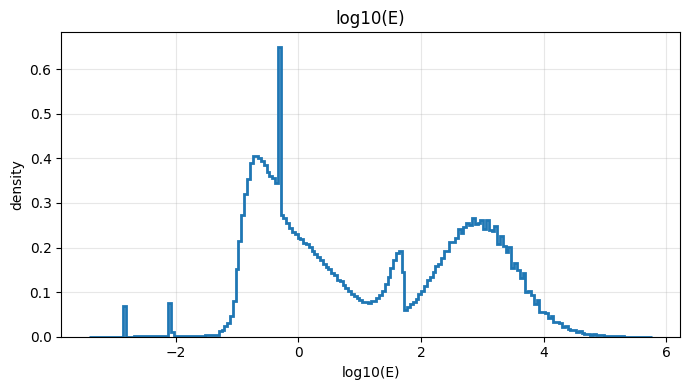

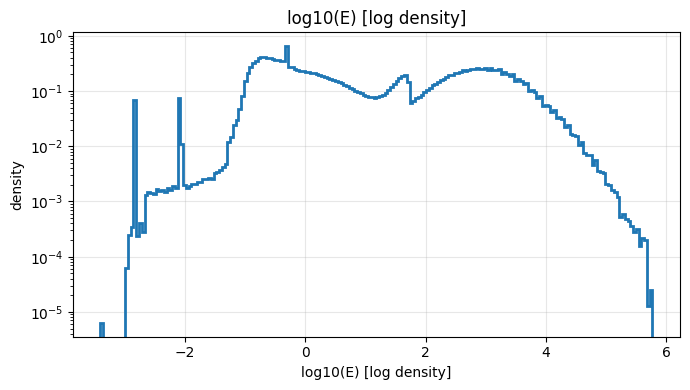

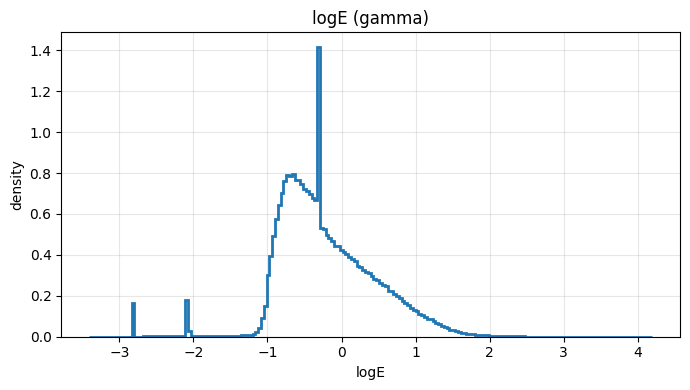

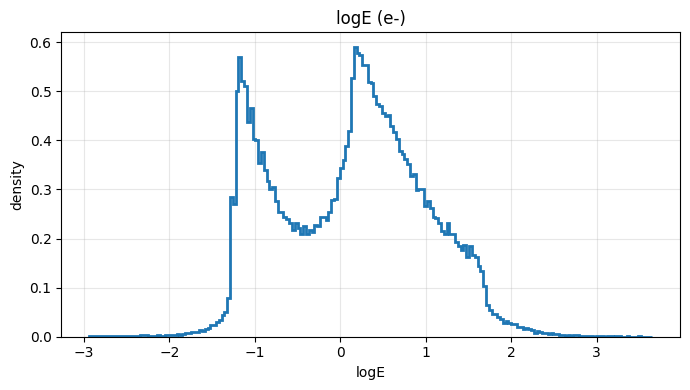

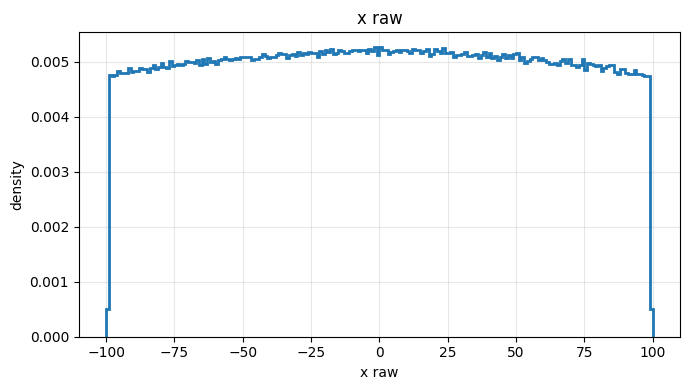

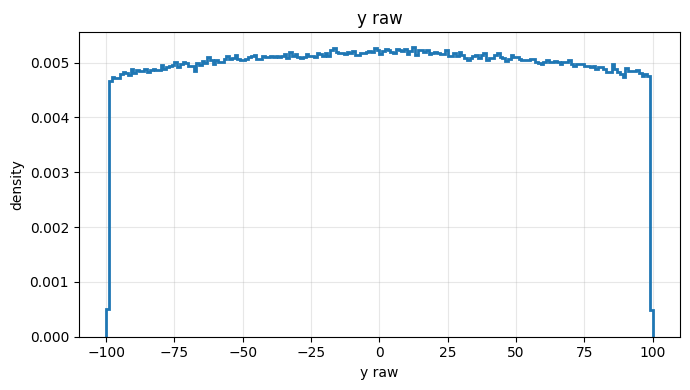

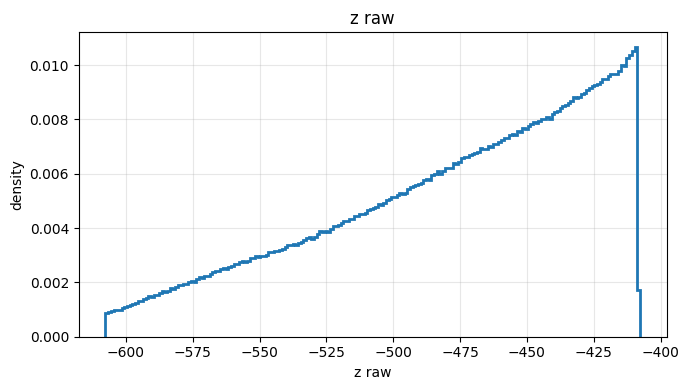

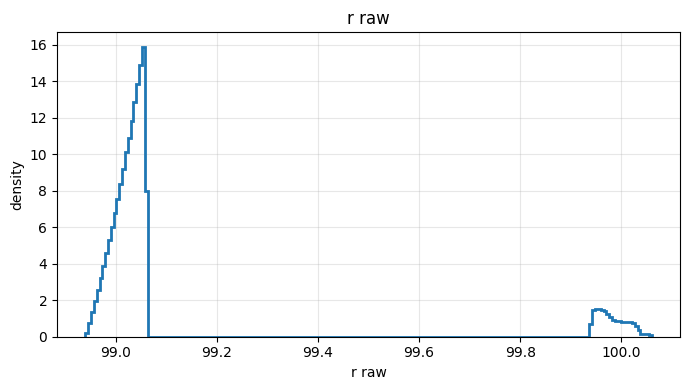

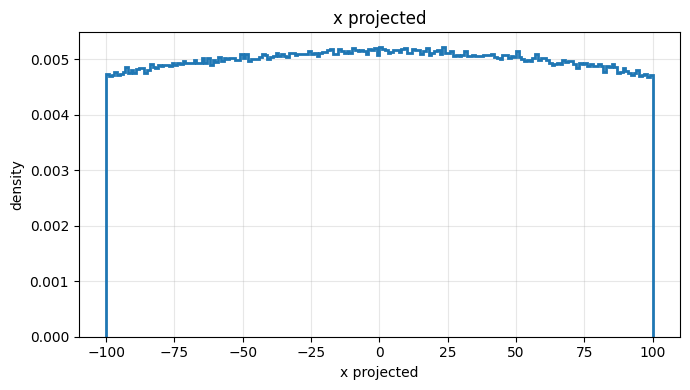

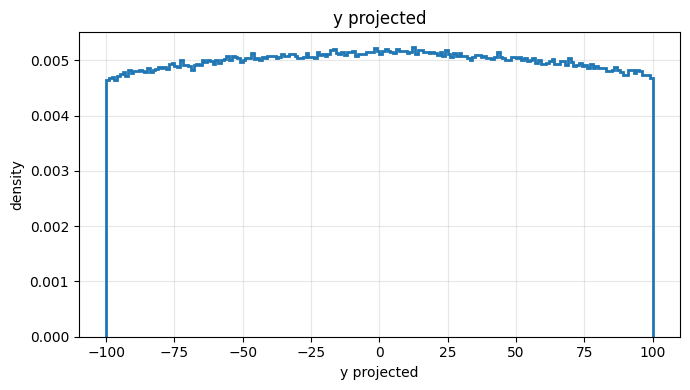

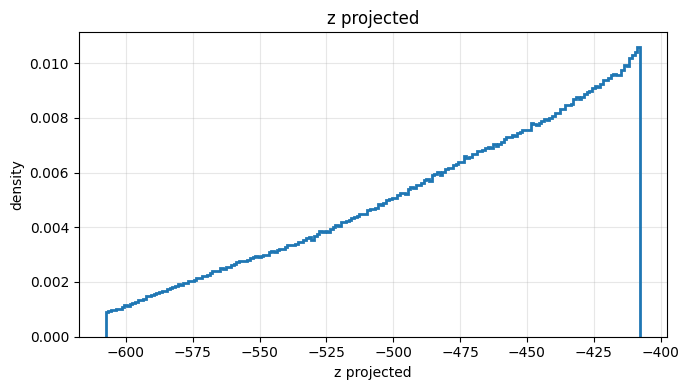

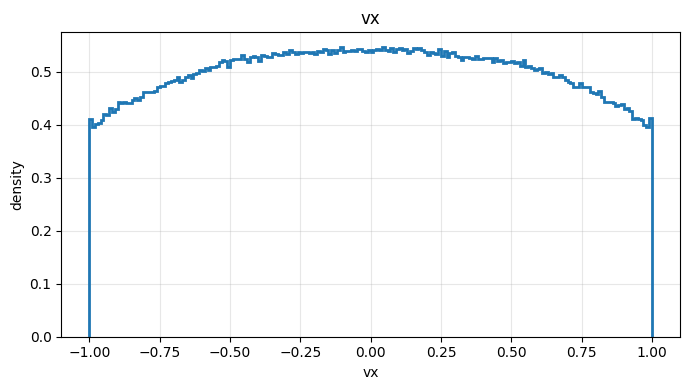

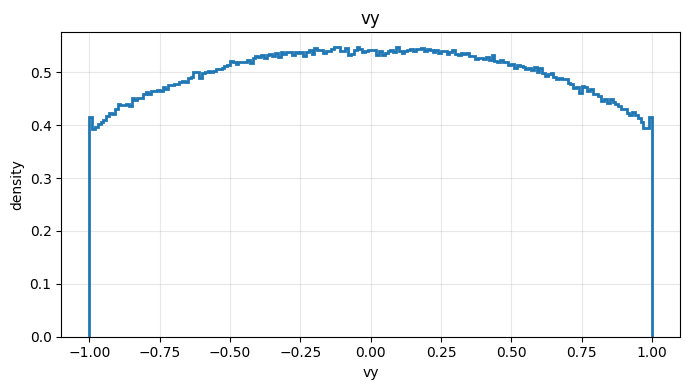

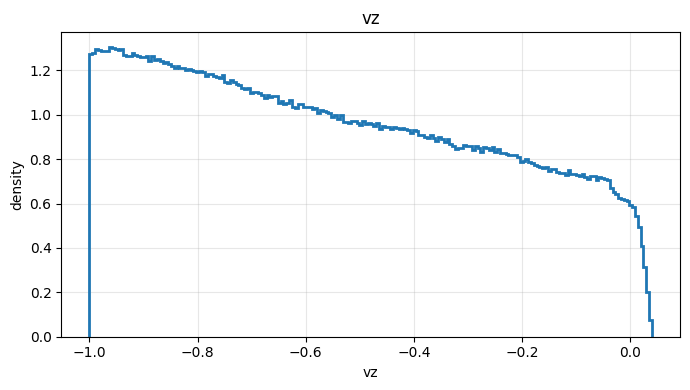

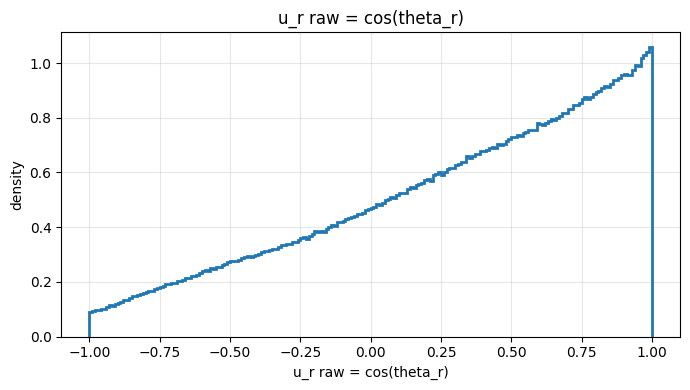

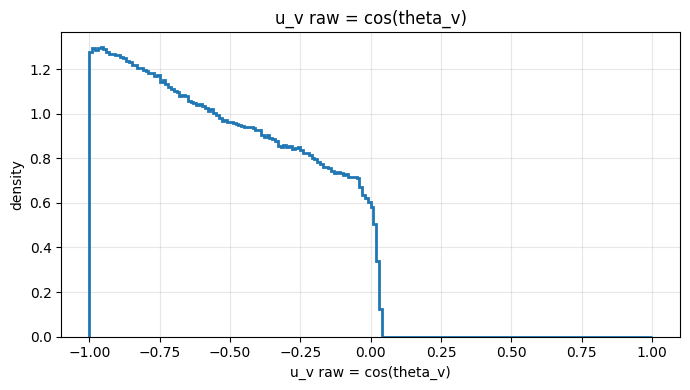

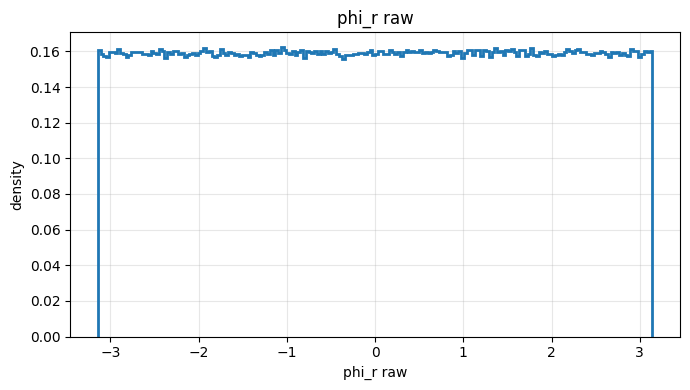

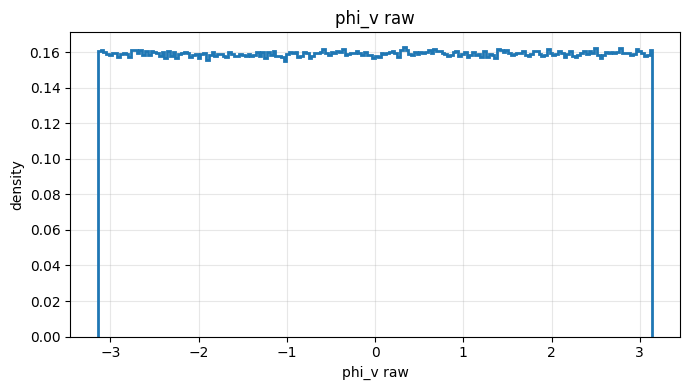

In [4]:
# ==========================================================
# Energy diagnostics from base physical features
# The v0.8 energy head models y = log10(E) directly (no binning), so the
# log-E shape below IS the target density the flow has to reproduce.
# ==========================================================

magi.plot_dist(feat_base["logE"], "log10(E)")
magi.plot_dist(feat_base["logE"], "log10(E) [log density]", yscale="log")
magi.plot_dist_by_class(feat_base, "logE", selected_class="gamma")
magi.plot_dist_by_class(feat_base, "logE", selected_class="e-")

# ==========================================================
# Raw / projected geometry
# ==========================================================

magi.plot_dist(raw["x"], "x raw")
magi.plot_dist(raw["y"], "y raw")
magi.plot_dist(raw["z"], "z raw")
magi.plot_dist(raw["r"], "r raw")

magi.plot_dist(proj["x"], "x projected")
magi.plot_dist(proj["y"], "y projected")
magi.plot_dist(proj["z"], "z projected")

magi.plot_dist(normdir["vx"], "vx")
magi.plot_dist(normdir["vy"], "vy")
magi.plot_dist(normdir["vz"], "vz")

# ==========================================================
# Raw physical geometry variables (unchanged from v0.7.2)
# ==========================================================

magi.plot_dist(feat_base["u_r"], "u_r raw = cos(theta_r)", range_=(-1, 1))
magi.plot_dist(feat_base["u_v"], "u_v raw = cos(theta_v)", range_=(-1, 1))
magi.plot_dist(feat_base["phi_r"], "phi_r raw", range_=(-np.pi, np.pi))
magi.plot_dist(feat_base["phi_v"], "phi_v raw", range_=(-np.pi, np.pi))

plt.show()

### Energy line detection

The mixture head is *told* where the lines are — their positions are fixed inputs
(`line_positions_y`), not learned — so getting them right matters more than any
tuning knob downstream. Detection matches statistically significant peaks against
the mass model's candidate table
(`CandidateLines/..._EADL.json`, built by
`tools/build_candidate_lines_from_geant4.py` from Geant4's own databases: the
atomic-relaxation tables for every element in the GDML mass model, and
PhotonEvaporation5.2 for the K-40 / Ra-226 / Th-232 / Rn-222 decay lines — no
values hand-typed from outside literature).

Three v0.8.1 corrections apply here:

- **EADL energies.** The table now takes its energies from `G4EMLOW7.3/fluor`
  (what Geant4 emits by default) while keeping the transition *labels* from
  `fluor_Bearden` (the only directory that ships them). The two differ by 17–43 eV
  — 4–11 detector FWHM — and the measured peaks match EADL to <1 eV.
- **Closest-pair matching.** Candidates used to claim peaks in JSON list order, so
  CR's ~8.0 keV Cu Kα peak was taken by Ni Kβ, 194 eV away, and modelled under the
  wrong label.
- **Sub-bin peak refinement** (`refine_bin_width_mev`). A detection bin is ~166 eV
  wide at 8 keV and ~21 keV at 511 keV on CR's log grid, so its centre is not a
  usable line position — without refinement the 511 keV peak matches Po-218.

Expected: instrumental fluorescence lines appear as `matched_lines`; the source
decay lines mostly appear as `unmatched_candidates`, since the sources sit in bulk
shielding and their primary gammas are Compton-degraded before crossing the
CryoSphere.

In [4]:
CANDIDATE_LINES_FILE = (
    f"{LINES_DIR}/"
    # v0.8.1: EADL energies - what Geant4 actually emitted. The Bearden
    # table this replaced pinned every fluorescence line 4-11 detector
    # FWHM away from its real peak (see docs/v0.8.1_line_truth.md).
    "CANDIDATE_ENERGY_LINES_SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed_EADL.json"
)

candidate_payload = magi.load_candidate_energy_lines(CANDIDATE_LINES_FILE)
candidate_lines = candidate_payload["lines"]

print(f"Loaded {candidate_payload['n_lines']} candidate lines "
      f"for mass model: {candidate_payload['mass_model']}")
print("Sources covered:", candidate_payload["sources"])

Loaded 113 candidate lines for mass model: SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed.gdml
Sources covered: ['K-40', 'Ra-226 chain', 'Rn-222 chain', 'Th-232 chain']


In [5]:
line_result = magi.detect_energy_lines(
    E_all,
    binning_mode="log_fixed_count",
    n_bins=1024,
    prominence_factor=3.0,
    window=5,
    candidate_lines=candidate_lines,
    # Refine each detected peak to the pinned line width before matching:
    # a detection bin is ~166 eV wide at 8 keV and ~21 keV at 511 keV on
    # CR's log grid, so its centre is not a usable line position.
    refine_bin_width_mev=X_IFU_RESOLUTION_EV * 1e-6,
)

magi.print_detected_energy_lines(line_result)

# Weak matches (single- to double-digit real counts out of millions of events)
# are filtered out before they feed the mixture head: a line slot the gate can
# never populate reliably only adds a spurious mixture component. Phase A above
# still reports every statistical match, for transparency; this filter is
# layered on top, here, not inside detect_energy_lines.
matched_all = line_result["matched_lines"]
matched = [m for m in matched_all if m["count"] >= 100]
dropped = [m for m in matched_all if m["count"] < 100]

print(f"\n{len(matched_all)} matched lines; {len(matched)} feed the mixture head "
      f"(count>=100): {[m['label'] for m in matched]}")
if dropped:
    print(f"  dropped as too weak (count<100): "
          f"{[(m['label'], int(m['count'])) for m in dropped]}")


--- Energy line detection ---
events: 3443885  bins: 1024  mode: log_fixed_count
candidate lines: 113  detected peaks: 5  matched: 5

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.510999 MeV detected=0.510999 MeV delta=+0.000000 MeV  count=61462
  Al K-alpha1          (instrumental          ) expected=0.001469 MeV detected=0.001469 MeV delta=-0.000000 MeV  count=10681
  Al K-beta            (instrumental          ) expected=0.001545 MeV detected=0.001545 MeV delta=-0.000000 MeV  count=73
  Cu K-alpha1          (instrumental          ) expected=0.008006 MeV detected=0.008006 MeV delta=-0.000000 MeV  count=7602
  Cu K-beta            (instrumental          ) expected=0.008865 MeV detected=0.008864 MeV delta=-0.000001 MeV  count=1505

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Al K-alpha2          (instrumental          ) expected=0.001469 MeV
  Si K-alpha1          (instrumental          ) expected=0.001721 MeV
  Si K-al

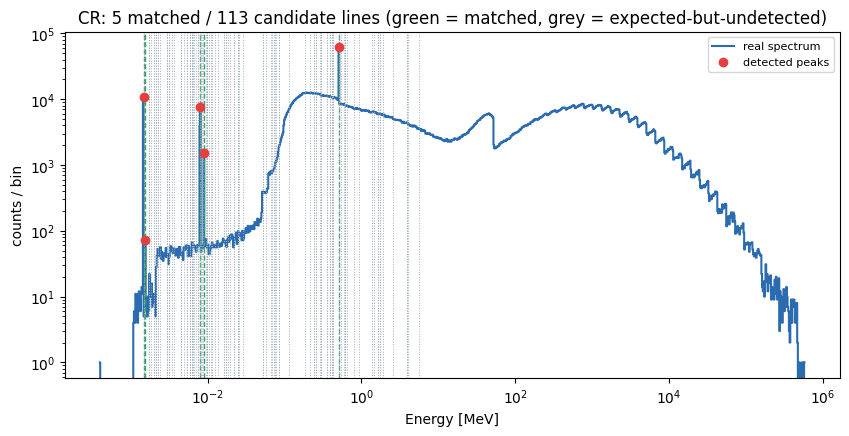

In [6]:
def plot_line_detection(name, E, result):
    edges = np.asarray(result["energy_bins"])
    centres = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(E, bins=edges)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.step(centres, counts, where="mid", color="#2b6cb0", label="real spectrum")

    for m in result["matched_lines"]:
        ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=1, ls="--")
    for c in result["unmatched_candidates"]:
        ax.axvline(c["candidate_energy_mev"], color="#a0aec0", lw=0.7, ls=":")

    peak_e = [p["energy_mev"] for p in result["detected_peaks"]]
    peak_c = [p["count"] for p in result["detected_peaks"]]
    ax.scatter(peak_e, peak_c, color="#e53e3e", zorder=5, label="detected peaks")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("counts / bin")
    ax.set_title(
        f"{name}: {result['n_matched']} matched / {result['n_candidate_lines']} "
        "candidate lines (green = matched, grey = expected-but-undetected)"
    )
    ax.legend(fontsize=8)
    plt.show()


plot_line_detection(SOURCE, E_all, line_result)

## Line-position audit (v0.8.1)

Before training anything, check the one input the mixture head cannot recover from:
**is each pinned line actually where the real events are?** With 4 eV widths, a line
misplaced by more than ~1 FWHM produces a generated peak that does not overlap the
real one at all — and the old bin-width recovery window was far too wide to notice.

This measures each matched line directly from the raw events at eV resolution:
centroid, width, line and continuum counts, and the offset from the catalogue value
in units of the pinned FWHM. Same computation as `tools/line_centroid_audit.py`.

In [7]:
FWHM_MEV = X_IFU_RESOLUTION_EV * 1e-6
SIGMA_MEV = FWHM_MEV / 2.3548200450309493

E_sorted = np.sort(E_all)


def audit_line(E_c, label, search_fwhm=20.0, fail_fwhm=1.0):
    """Measure the real peak near E_c: centroid, width, line/continuum split."""
    half = search_fwhm * FWHM_MEV
    lo, hi = E_c - half, E_c + half
    i0, i1 = np.searchsorted(E_sorted, [lo, hi])
    sub = E_sorted[i0:i1]
    if sub.size < 10:
        return {"label": label, "verdict": "absent"}

    step = FWHM_MEV / 2.0
    nb = max(int(round((hi - lo) / step)), 8)
    hist, edges = np.histogram(sub, bins=nb, range=(lo, hi))
    med = float(np.median(hist))
    k = int(np.argmax(hist))
    if hist[k] < max(10.0, 5.0 * max(med, 1.0)):
        return {"label": label, "verdict": "absent"}

    thr = max(med * 2.0, 1.0)
    a = b = k
    while a > 0 and hist[a - 1] > thr:
        a -= 1
    while b < nb - 1 and hist[b + 1] > thr:
        b += 1
    core = sub[(sub >= edges[a]) & (sub < edges[b + 1])]
    n_cont = med * (b - a + 1)
    centroid = float(core.mean())
    std = float(core.std(ddof=1)) if core.size > 1 else 0.0
    delta = E_c - centroid
    return {
        "label": label, "verdict": "ok",
        "catalogue_keV": E_c * 1e3,
        "measured_keV": centroid * 1e3,
        "delta_eV": delta * 1e6,
        "delta_FWHM": abs(delta) / FWHM_MEV,
        "measured_FWHM_eV": std * 2.3548200450309493 * 1e6,
        "n_line": max(core.size - n_cont, 0.0),
        "pass": abs(delta) / FWHM_MEV <= fail_fwhm,
    }


audit = [audit_line(float(m["candidate_energy_mev"]), m["label"]) for m in matched]
audit_df = pd.DataFrame(audit)
print(f"{SOURCE}: line-position audit against the pinned {X_IFU_RESOLUTION_EV} eV FWHM\n")
print(audit_df.to_string(index=False))

bad = [a for a in audit if a["verdict"] != "ok" or not a["pass"]]
if bad:
    print(f"\n*** {len(bad)} line(s) are pinned more than 1 FWHM from their real peak - "
          f"the mixture head cannot reproduce them. Fix the candidate table before "
          f"training. ***")
else:
    print(f"\nAll {len(audit)} lines are within 1 FWHM of their measured position.")

CR: line-position audit against the pinned 4.0 eV FWHM

            label verdict  catalogue_keV  measured_keV  delta_eV  delta_FWHM  measured_FWHM_eV  n_line  pass
e+e- annihilation      ok      510.99900    510.999000 -0.000096    0.000024          0.023040 52226.0  True
      Al K-alpha1      ok        1.46917      1.469013  0.157401    0.039350          0.522367 10670.0  True
      Cu K-alpha1      ok        8.00571      8.005710 -0.000121    0.000030          0.024673  7542.0  True
        Cu K-beta      ok        8.86534      8.865341 -0.001135    0.000284          0.083212   969.0  True

All 4 lines are within 1 FWHM of their measured position.


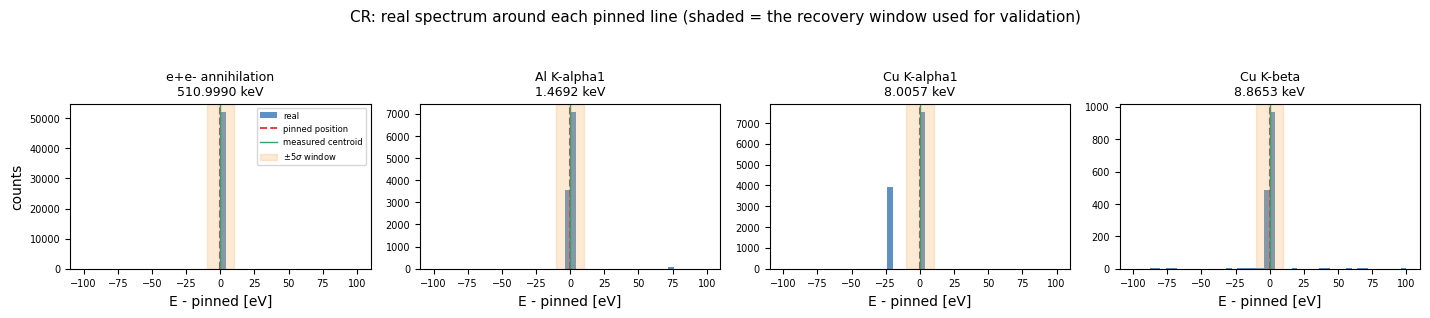

In [8]:
# Visual proof at line scale: the real spectrum in a +/-25 FWHM window around each
# line, with the pinned position marked. (With the Bearden table these markers sat
# 4-11 FWHM off the peak - visible here as a marker beside an empty bin.)

n_ax = len(matched)
fig, axes = plt.subplots(1, n_ax, figsize=(3.6 * n_ax, 3.2))
axes = np.atleast_1d(axes)
for ax, m, a in zip(axes, matched, audit):
    E_c = float(m["candidate_energy_mev"])
    half = 25 * FWHM_MEV
    sel = E_all[(E_all >= E_c - half) & (E_all <= E_c + half)]
    ax.hist((sel - E_c) * 1e6, bins=50, range=(-half * 1e6, half * 1e6),
            color="#2b6cb0", histtype="stepfilled", alpha=0.75, label="real")
    ax.axvline(0.0, color="#e53e3e", lw=1.4, ls="--", label="pinned position")
    if a["verdict"] == "ok":
        ax.axvline(-a["delta_eV"], color="#38a169", lw=1.0, label="measured centroid")
    ax.axvspan(-2.5 * X_IFU_RESOLUTION_EV, 2.5 * X_IFU_RESOLUTION_EV,
               color="#f6ad55", alpha=0.25, label=r"$\pm 5\sigma$ window")
    ax.set_title(f"{m['label']}\n{E_c*1e3:.4f} keV", fontsize=9)
    ax.set_xlabel("E - pinned [eV]")
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("counts")
axes[0].legend(fontsize=6)
fig.suptitle(f"{SOURCE}: real spectrum around each pinned line "
             f"(shaded = the recovery window used for validation)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Standardization and Preprocessing

Same pipeline as v0.7.2 — `build_feature_dataframe` → `filter_particle_types_
continuous_geometry` → `split_feature_data` → `scale_continuous_features` →
`build_conditioning_and_weights` → `build_tf_datasets` — with three additions:

1. `energy_transform="log10"`: energy enters as the continuous column
   `energy_y = log10(E)` rather than a bin index.
2. **Gate targets** labelling each event continuum-or-line, now with a
   **resolution-driven bandwidth** (v0.8.1, defect D).
3. **CDF warp knots** for the continuum flow.

In [9]:
feature_pack = magi.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    n_bins=512,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=10000,
    random_state=42,
    # v0.8: continuous energy target y = log10(E) alongside the bin index
    energy_transform="log10",
)
del prep  # superseded by feature_pack["filtered_prep"] from here on - the
# raw/proj/normdir/derived/feat_base aliases from cell 4 stay valid, they
# reference prep's underlying arrays directly, not the prep dict itself.

magi.report_feature_dataframe(feature_pack)

energy_bins = feature_pack["energy_bins"]
n_energy_bins = feature_pack["n_energy_bins"]

quantile_transformers = feature_pack["quantile_transformers"]
qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

geometry_metadata = feature_pack["geometry_metadata"]

print("Feature columns:", feature_pack["feat"].columns.tolist())
print("Geometry metadata:", geometry_metadata)


feat shape: (3443885, 7)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  energy_y
0        gamma    165 -1.197646  0.980098 -0.377857  0.582957 -0.434824
1          mu-    349 -1.144044  1.709177  0.820844 -0.336785  2.855079
2        gamma    182  0.343266 -1.461600  0.343946  1.330176 -0.130861
3    anti_nu_e    266  1.178254 -1.766368  0.092314  0.894929  1.365965
4        gamma    157 -1.100084  1.795517 -0.323269 -2.385135 -0.579892

--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  511
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393
  energy_y : -3.405198812484741  5.766048908233643

--- Quantile geometry checks ---
u_r_q: mean = -0.000545, std = 0.996885, min = -5.199337, max = 5.199337
u_v_q: mean = 0.002369, std = 1

In [10]:
# ==========================================================
# v0.8.1 line inputs + gate targets
#
# The gate-target bandwidth is now set by the PINNED LINE WIDTH, not by the
# detection bin width. The bin-width bandwidth was +/-125 eV at 1.49 keV,
# +/-320 eV at 8.9 keV and +/-43 keV at 511 keV - 31 to 10,000 detector FWHM -
# so every event in that neighbourhood was labelled a line event and the gate was
# supervised to over-route by roughly that ratio. That is the mechanism behind
# v0.8's 5.8x over-generated 511 line and the continuum holes beside the lines.
# ==========================================================

line_positions_mev = np.array([m["candidate_energy_mev"] for m in matched], dtype=np.float64)
line_positions_y = np.log10(line_positions_mev).astype(np.float32)

E_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()

# v0.8.2 follow-up: bandwidth_mode="exact" (exact energy match, since raw
# Geant4 data has no detector response and lines are truly monoenergetic) was
# tried and REJECTED - measured on CR it left Cu Kalpha1 unchanged and broke
# both the Al Kalpha1 fix below and the coupling bar (docs/v0.8.1_line_truth.md
# section 14.2). "resolution" remains the default.
gate_targets = magi.build_gate_targets(
    E_full,
    feature_pack["energy_bins"],
    matched,
    bandwidth_mode="resolution",          # v0.8.1, confirmed again in v0.8.2
    bandwidth_fwhm_mev=FWHM_MEV,
)

# Legacy targets, for the diagnostic below only
gate_targets_bins = magi.build_gate_targets(E_full, feature_pack["energy_bins"], matched)

feat = feature_pack["feat"].copy()
for j in range(gate_targets.shape[1]):
    feat[f"gate_target_{j}"] = gate_targets[:, j]

cont_cols = ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q", "energy_y") + tuple(
    f"gate_target_{j}" for j in range(gate_targets.shape[1])
)

# How much of the data each mode labels as a line, against the truth measured in
# the audit above. 1.0 = the gate is asked to route exactly the real line rate.
print(f"{SOURCE}: gate-target line mass vs the true line fraction\n")
print(f"  {'line':22s} {'true':>10s} {'bins mode':>12s} {'resolution':>12s}")
for j, (m, a) in enumerate(zip(matched, audit)):
    true_frac = (a["n_line"] / E_full.size) if a["verdict"] == "ok" else float("nan")
    f_bins = gate_targets_bins[:, j + 1].mean()
    f_res = gate_targets[:, j + 1].mean()
    print(f"  {m['label']:22s} {true_frac:10.5f} "
          f"{f_bins:9.5f} ({f_bins/true_frac:4.2f}x) "
          f"{f_res:9.5f} ({f_res/true_frac:4.2f}x)")
print(f"\ny_cont columns: {cont_cols}")
print(f"line_positions_y (log10 E): {line_positions_y}")

CR: gate-target line mass vs the true line fraction

  line                         true    bins mode   resolution
  e+e- annihilation         0.01516   0.05234 (3.45x)   0.01487 (0.98x)
  Al K-alpha1               0.00310   0.00275 (0.89x)   0.00304 (0.98x)
  Cu K-alpha1               0.00219   0.00277 (1.26x)   0.00216 (0.99x)
  Cu K-beta                 0.00028   0.00078 (2.75x)   0.00042 (1.48x)

y_cont columns: ('u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3', 'gate_target_4')
line_positions_y (log10 E): [-0.29157996 -2.832928   -2.0966     -2.0523045 ]


In [11]:
dataset_pack = magi.filter_particle_types_continuous_geometry(
    feat=feat,
    prob_threshold=1e-5,
    cont_cols=cont_cols,
)

magi.report_continuous_geometry_features(dataset_pack)



Dataset mode: continuous_geometry
Continuous geometry version: custom_continuous_geometry
Kept particle types: 6
Types: ['gamma', 'mu-', 'e-', 'anti_nu_e', 'nu_mu', 'e+']

Empirical probabilities:
       gamma  p=5.032918e-01
         mu-  p=4.172242e-01
          e-  p=3.211547e-02
   anti_nu_e  p=2.303271e-02
       nu_mu  p=2.300193e-02
          e+  p=1.333959e-03

Shapes:
X_cont_raw: (3443885, 10)
E_idx     : (3443885,)
y_type    : (3443885,)

--- Continuous feature ranges ---
   u_r_q : -5.199337482452393  5.199337482452393
   u_v_q : -5.199337482452393  5.199337482452393
 phi_r_q : -5.199337482452393  5.199337482452393
 phi_v_q : -5.199337482452393  5.199337482452393
energy_y : -3.405198812484741  5.766048908233643
gate_target_0 : 0.019607843831181526  1.0
gate_target_1 : 0.0  0.9803921580314636
gate_target_2 : 0.0  0.9803921580314636
gate_target_3 : 0.0  0.9803921580314636
gate_target_4 : 0.0  0.9803921580314636

--- Continuous means/std ---
   u_r_q : mean=-0.000545  std= 0.99

In [12]:
# ==========================================================
# v0.8.2 Phase C candidate 1: per-type zone probabilities
#
# The learned prior p(z|cond) is trained on z ~ q(z|x), where the real event's
# gate-target columns are visible, but generation draws z ~ p(z|cond) with NO
# real event to read the zone from. prior_zone_conditioning widens cond from
# [type] to [type, zone] at TRAIN time (the real gate target); at GENERATION
# time the zone is instead sampled from each type's empirical zone frequency
# computed here. Confirmed on CR, 3 seeds: CR Al Kalpha1 recovery
# 0.702+/-0.290 (FAIL) -> 0.959+/-0.025 (PASS), coupling unaffected
# (docs/v0.8.1_line_truth.md section 14). Computed unconditionally - it is
# cheap, and this is the first v0.8.2 measurement of it on a non-CR source.
# ==========================================================

n_zones = gate_targets.shape[1]
zone_cols = dataset_pack["X_cont_raw"][:, -n_zones:]
y_type_for_zones = dataset_pack["y_type"]

zone_probs = np.zeros((dataset_pack["n_types"], n_zones), dtype=np.float64)
for t in range(dataset_pack["n_types"]):
    mask = (y_type_for_zones == t)
    row = zone_cols[mask].mean(axis=0) if mask.any() else np.zeros(n_zones)
    row_sum = row.sum()
    zone_probs[t] = (row / row_sum) if row_sum > 0 else np.eye(n_zones)[0]

zone_labels = ["continuum"] + [m["label"] for m in matched]
print(f"{SOURCE}: zone_probs (per type, {zone_labels}):")
for t, tname in dataset_pack["idx_to_type"].items():
    print(f"    {tname:12s} {np.round(zone_probs[t], 4)}")


CR: zone_probs (per type, ['continuum', 'e+e- annihilation', 'Al K-alpha1', 'Cu K-alpha1', 'Cu K-beta']):
    gamma        [9.593e-01 2.960e-02 6.000e-03 4.300e-03 8.000e-04]
    mu-          [1. 0. 0. 0. 0.]
    e-           [1. 0. 0. 0. 0.]
    anti_nu_e    [1. 0. 0. 0. 0.]
    nu_mu        [1. 0. 0. 0. 0.]
    e+           [1. 0. 0. 0. 0.]


Train: (2410719, 10) Val: (516583, 10) Test: (516583, 10)

Type distribution check:
Train: [0.50329176 0.41722407 0.03211531 0.02303296 0.02300185 0.00133404]
Val  : [0.50329182 0.41722434 0.03211488 0.02303212 0.02300308 0.00133376]
Test : [0.50329182 0.41722434 0.03211681 0.02303212 0.02300114 0.00133376]
No StandardScaler applied.
scale_cols: ()

--- Train continuous means/std ---
     u_r_q: mean=-0.000681  std= 0.996909
     u_v_q: mean= 0.002334  std= 1.005952
   phi_r_q: mean= 0.006945  std= 0.999596
   phi_v_q: mean=-0.003632  std= 1.010150
  energy_y: mean= 1.180365  std= 1.642114
gate_target_0: mean= 0.979531  std= 0.140130
gate_target_1: mean= 0.014847  std= 0.119730
gate_target_2: mean= 0.003065  std= 0.054725
gate_target_3: mean= 0.002147  std= 0.045702
gate_target_4: mean= 0.000411  std= 0.020051

cond_train shape: (2410719, 6)
cond_val shape  : (516583, 6)
cond_test shape : (516583, 6)

Example one-hot rows:
tf.Tensor(
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0.

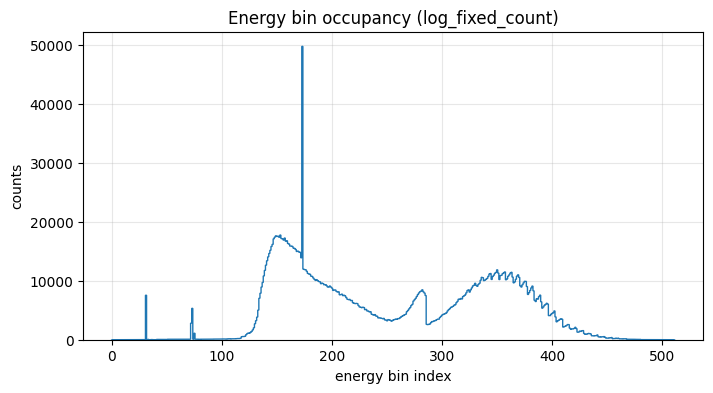

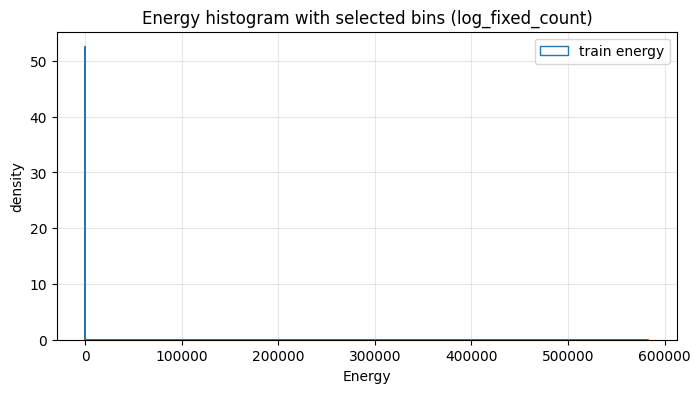

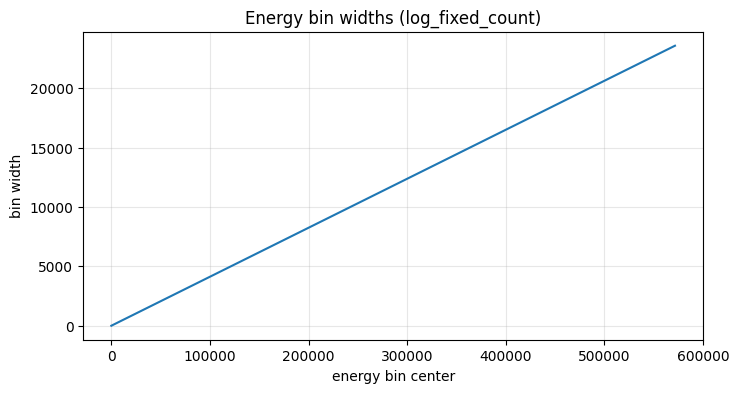

In [13]:
split_pack = magi.split_feature_data(
    dataset_pack,
    test_size_total=0.30,
    val_size_from_temp=0.50,
    random_state=42,
)

magi.report_split_summary(split_pack, n_types=dataset_pack["n_types"])

scaled_pack = magi.scale_continuous_features(
    split_pack,
    scale_cols=(),
)

magi.report_scaled_features(scaled_pack)

condition_pack = magi.build_conditioning_and_weights(
    scaled_pack,
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    alpha=0.5,
)

magi.report_conditioning(condition_pack, n_types=dataset_pack["n_types"])

tf_pack = magi.build_tf_datasets(
    condition_pack,
    batch_size=4096,
    shuffle_buffer_cap=200_000,
)

magi.report_tf_datasets(tf_pack)

magi.report_energy_binning_diagnostics(
    energy_bins=feature_pack["energy_bins"],
    E_idx=dataset_pack["E_idx"],
    E_values=feature_pack["filtered_prep"]["features"]["Energy"].to_numpy(),
    idx_train=split_pack["idx_train"],
    energy_binning_mode=feature_pack["energy_config"]["mode"],
    bin_width=feature_pack["energy_config"]["bin_width"],
    n_bins=feature_pack["energy_config"]["n_bins"],
    min_counts=feature_pack["energy_config"]["min_counts"],
)

In [14]:
# ==========================================================
# Recover all main objects from package outputs - v0.8
# ==========================================================

feat = dataset_pack["feat"]

# model-side continuous block: [u_r_q, u_v_q, phi_r_q, phi_v_q, energy_y, gate_*]
X_cont_train_s = tf_pack["X_cont_train_s"]
X_cont_val_s = tf_pack["X_cont_val_s"]
X_cont_test_s = tf_pack["X_cont_test_s"]

X_cont_train = tf_pack["X_cont_train"]
X_cont_val = tf_pack["X_cont_val"]
X_cont_test = tf_pack["X_cont_test"]

# energy bin indices: kept for diagnostics/validation only - the v0.8 head does
# NOT consume them (it reads energy_y, column 4 of X_cont).
E_train = tf_pack["E_train"]
E_val = tf_pack["E_val"]
E_test = tf_pack["E_test"]

cond_train = tf_pack["cond_train"]
cond_val = tf_pack["cond_val"]
cond_test = tf_pack["cond_test"]

train_ds = tf_pack["train_ds"]
val_ds = tf_pack["val_ds"]
test_ds = tf_pack["test_ds"]

type_weights = tf_pack["type_weights"]

n_types = dataset_pack["n_types"]
idx_to_type = dataset_pack["idx_to_type"]
type_probs = dataset_pack["type_probs"]

cont_cols = dataset_pack["cont_cols"]
Y_CONT_DIM = X_cont_train_s.shape[1]
N_LINES = int(len(matched))

# raw physical references, per split
features_filtered = feature_pack["filtered_prep"]["features"]

E_all_filtered = features_filtered["Energy"].to_numpy()
u_r_all_raw = features_filtered["u_r"].to_numpy()
u_v_all_raw = features_filtered["u_v"].to_numpy()
phi_r_all_raw = features_filtered["phi_r"].to_numpy()
phi_v_all_raw = features_filtered["phi_v"].to_numpy()

idx_train = split_pack["idx_train"]
idx_val = split_pack["idx_val"]
idx_test = split_pack["idx_test"]

E_train_raw = E_all_filtered[idx_train]
E_val_raw = E_all_filtered[idx_val]
E_test_raw = E_all_filtered[idx_test]

print("Y_CONT_DIM:", Y_CONT_DIM, "(4 geometry + 1 energy_y + %d gate slots)" % (N_LINES + 1))
print("cont_cols :", cont_cols)
print("n_types   :", n_types, idx_to_type)
print("n_lines   :", N_LINES)
print("Available quantile transformers:", list(quantile_transformers.keys()))

Y_CONT_DIM: 10 (4 geometry + 1 energy_y + 5 gate slots)
cont_cols : ['u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3', 'gate_target_4']
n_types   : 6 {0: 'gamma', 1: 'mu-', 2: 'e-', 3: 'anti_nu_e', 4: 'nu_mu', 5: 'e+'}
n_lines   : 4
Available quantile transformers: ['qt_u_r', 'qt_u_v', 'qt_phi_r', 'qt_phi_v']


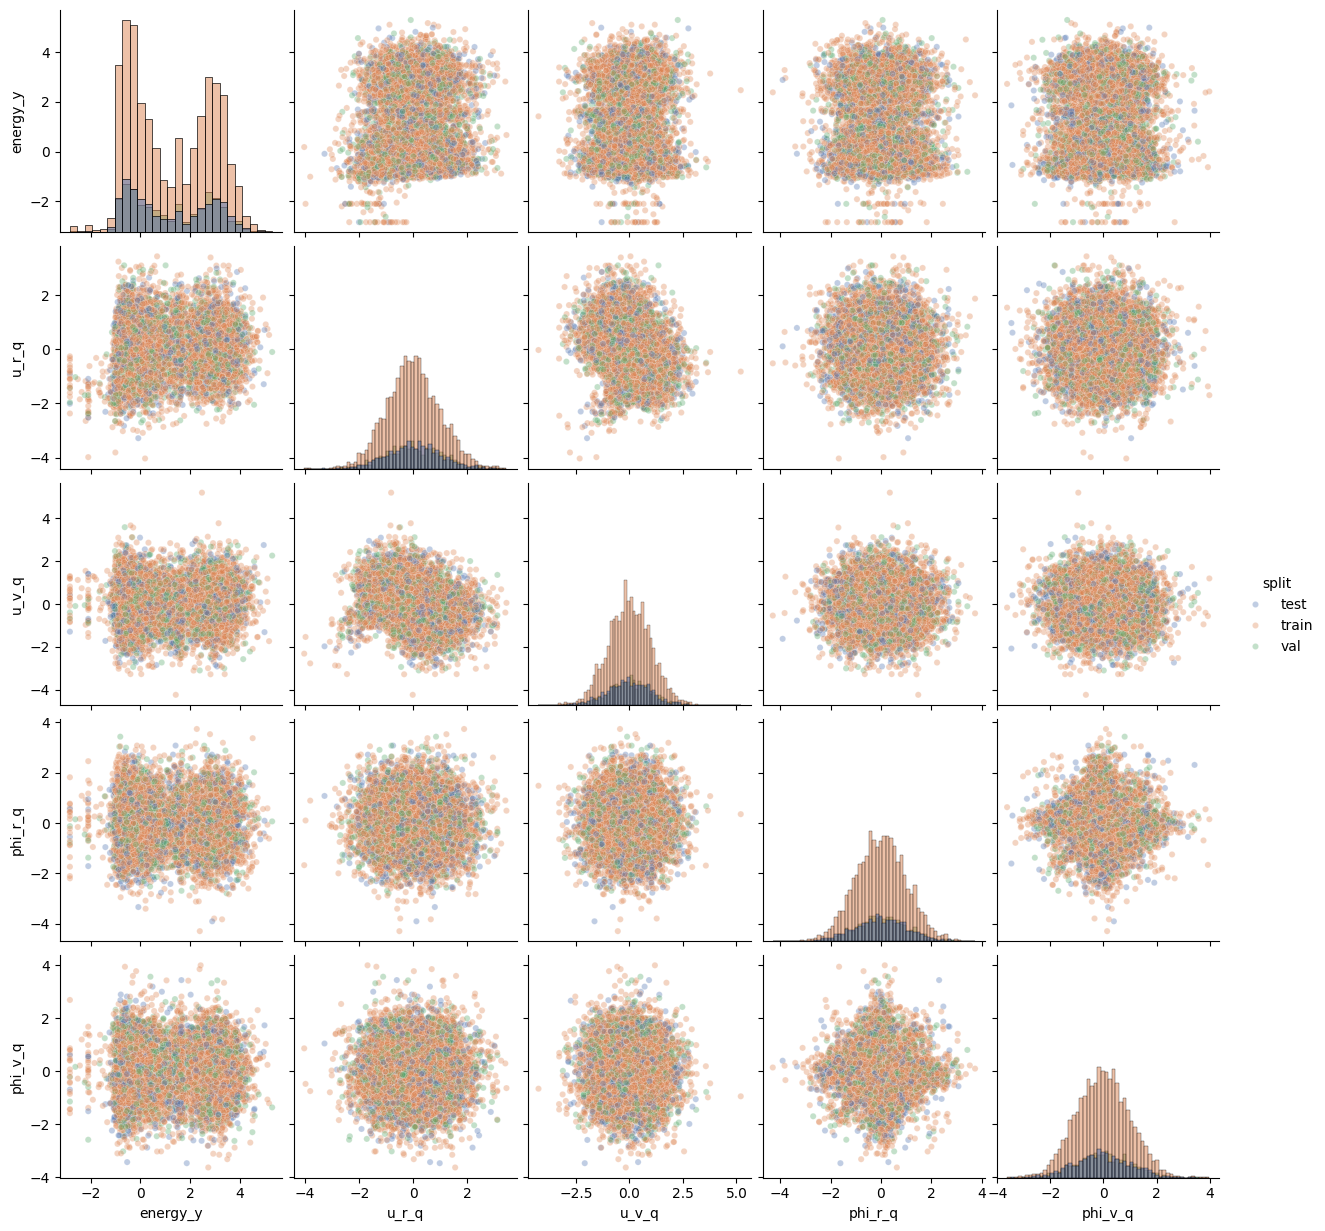

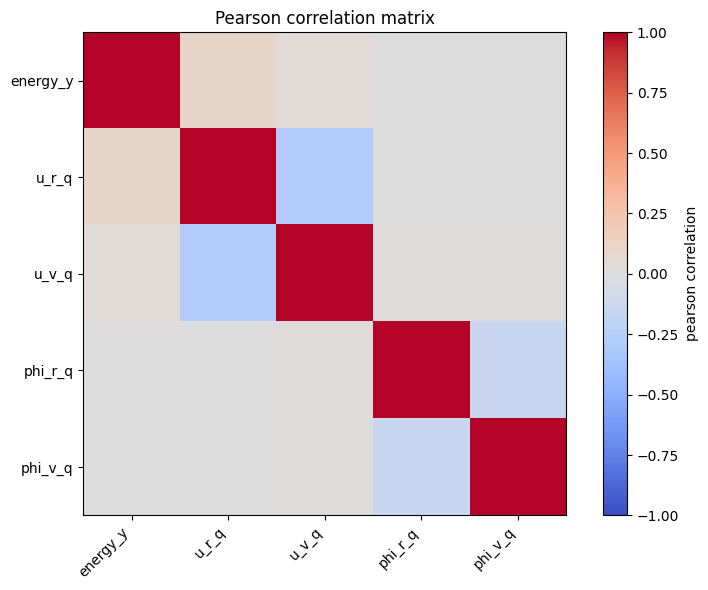

In [15]:
# ==========================================================
# Split sanity: the three splits must be statistically identical
# ==========================================================

df_train_plot = dataset_pack["feat"].iloc[split_pack["idx_train"]].copy()
df_val_plot   = dataset_pack["feat"].iloc[split_pack["idx_val"]].copy()
df_test_plot  = dataset_pack["feat"].iloc[split_pack["idx_test"]].copy()

df_train_plot["split"] = "train"
df_val_plot["split"]   = "val"
df_test_plot["split"]  = "test"

df_all_splits = pd.concat(
    [df_train_plot, df_val_plot, df_test_plot],
    axis=0,
    ignore_index=True,
)

model_space_cols = ["energy_y", "u_r_q", "u_v_q", "phi_r_q", "phi_v_q"]

magi.plot_pairwise_sample(
    df_all_splits,
    cols=model_space_cols,
    class_col="split",
    sample_size=8000,
)

magi.plot_correlation_matrix(
    df_all_splits,
    model_space_cols,
    method="pearson",
)

plt.show()

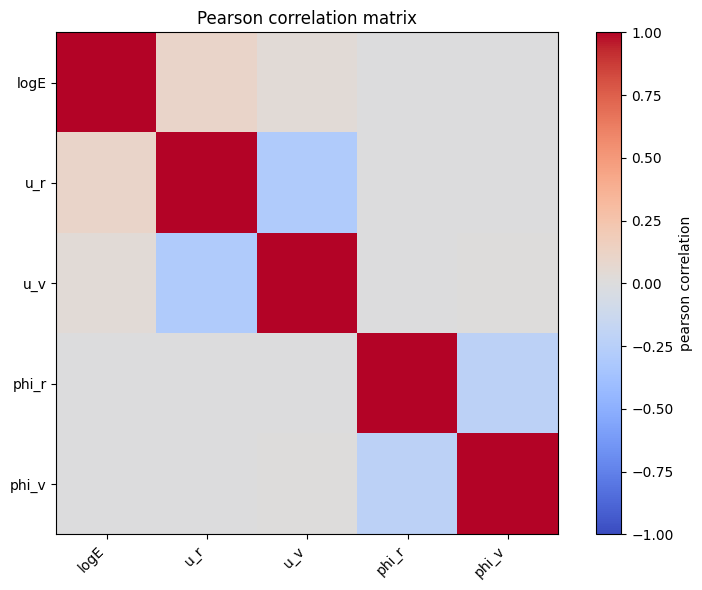

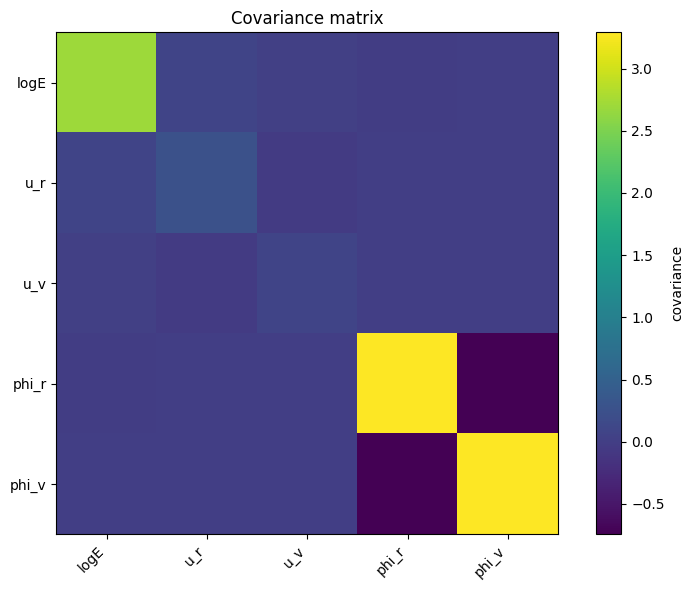

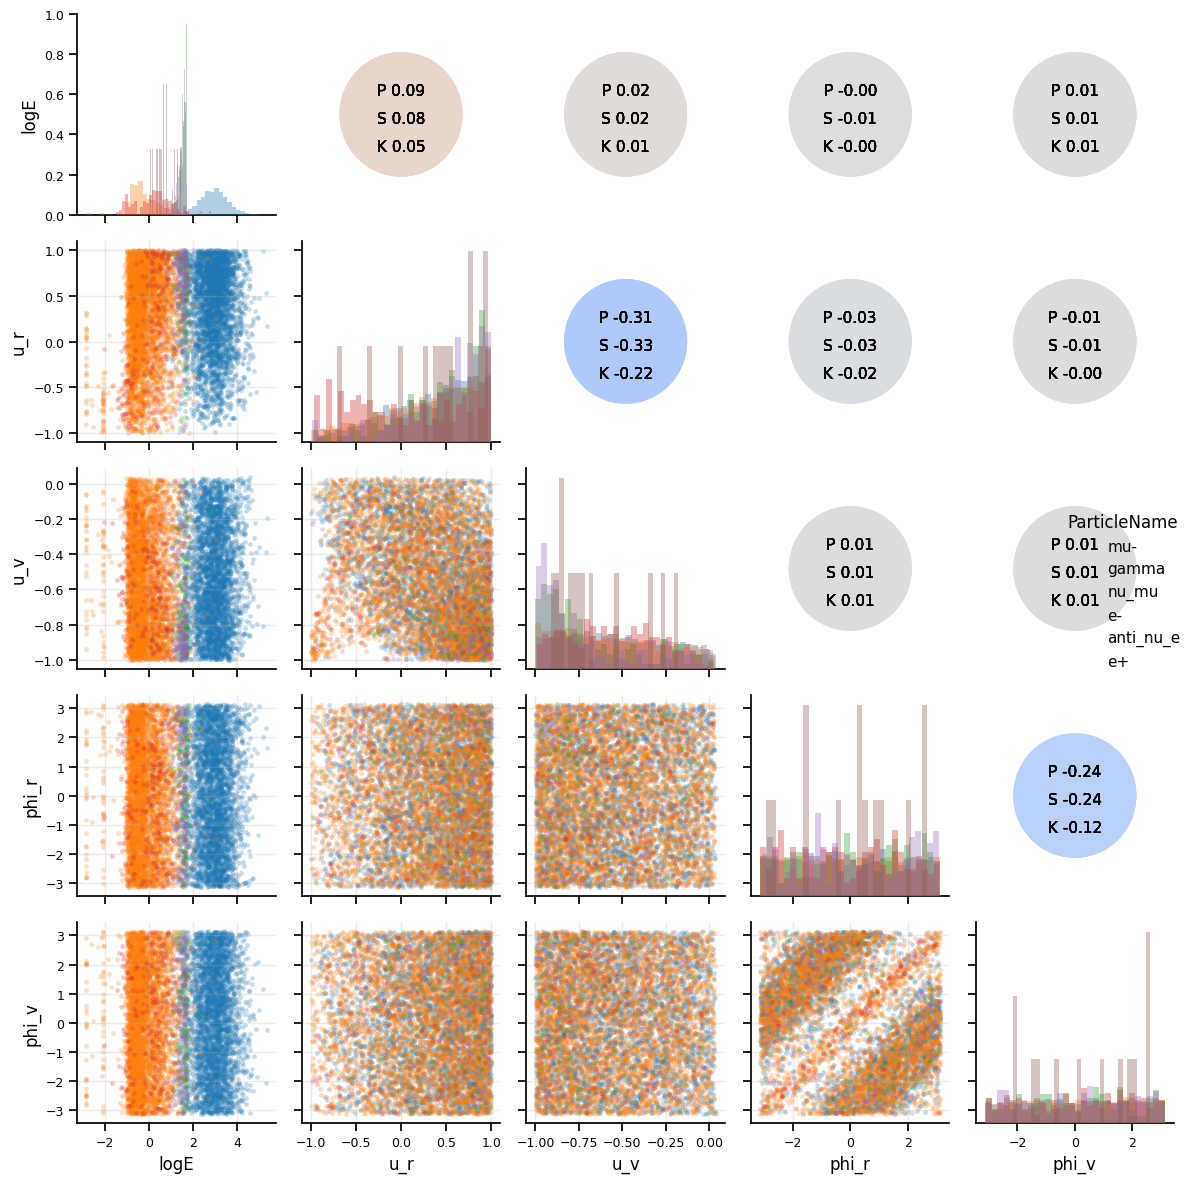

In [16]:
# ==========================================================
# Real-data structure the model has to reproduce: correlation, covariance and
# the full pairgrid over the physical variables. These are the reference for
# the identical plots on generated events in the validation section.
# ==========================================================

corr_df = feature_pack["filtered_prep"]["features"].copy()
corr_df["logE"] = np.log10(corr_df["Energy"].to_numpy())

corr_cols_phys = ["logE", "u_r", "u_v", "phi_r", "phi_v"]

corr_real = magi.plot_correlation_matrix(corr_df, corr_cols_phys, method="pearson")
cov_real = magi.plot_covariance_matrix(corr_df, corr_cols_phys)

magi.plot_pairgrid_physics(
    corr_df,
    cols=corr_cols_phys,
    class_col="ParticleName",
    sample_size=8000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
    theme="light",
    palette="tab10",
)

plt.show()

CDF warp: 256 knots over y in [-2.833, 5.331] -> z in [-3.72, 3.72]
affine reference (NOT used): y_mean=1.180 y_scale=1.642


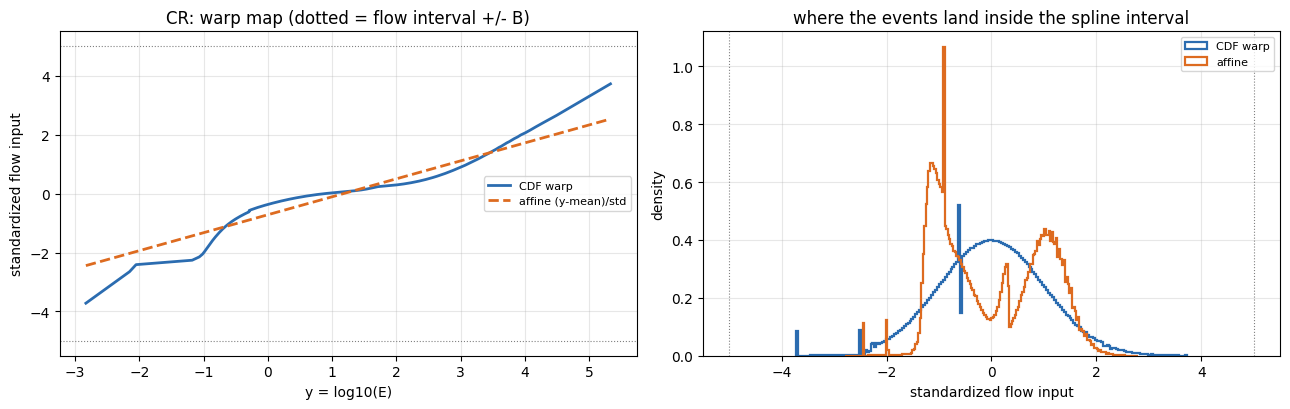

In [17]:
# ==========================================================
# CDF pre-warp knots for the flow continuum  (v0.8 Cycle 1)
#
# The RQS flow warps a FIXED interval [-B, B] (B = interval_half_width = 5) in
# standardized space, with frozen N(0,1) tails outside it. With plain affine
# standardization (y - mean)/std that interval is allocated by *variance*, not
# by where the events are:
#   - CR: the muon tail (to ~1e6 MeV) inflates the std, so the low-energy bulk
#     occupies a tiny slice of [-5, 5] and too few spline knots land on the
#     Compton edge -> it comes out over-smoothed.
#   - Small: the bulk is narrow, so the sparse low-energy tail lands near/beyond
#     B=5 -> the frozen normal tails take over and the tail density collapses.
#
# fit_cdf_warp_knots builds a monotone empirical-CDF -> N(0,1) map instead, so the
# knots are density-proportional: every quantile of the data gets comparable
# spline resolution and nothing falls outside the modelled interval. Validated on
# the --sparse-tail synthetic: deep-tail window ratio 0.00 (affine) -> 0.96 (cdf).
# See docs/v0.8_v072_comparison.md sec 6(b) and sec 9.
# ==========================================================

energy_y_all = feat["energy_y"].to_numpy()

warp_y_knots, warp_z_knots = magi.fit_cdf_warp_knots(
    energy_y_all,
    n_knots=256,
    eps=1e-4,
)

y_mean_affine = float(energy_y_all.mean())
y_scale_affine = float(energy_y_all.std())

print(f"CDF warp: {warp_y_knots.size} knots over "
      f"y in [{warp_y_knots[0]:.3f}, {warp_y_knots[-1]:.3f}] "
      f"-> z in [{warp_z_knots[0]:.2f}, {warp_z_knots[-1]:.2f}]")
print(f"affine reference (NOT used): y_mean={y_mean_affine:.3f} y_scale={y_scale_affine:.3f}")

# What the two standardizations do to the same data: the fraction of [-5, 5]
# that the physically interesting bulk actually occupies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(warp_y_knots, warp_z_knots, color="#2b6cb0", lw=2, label="CDF warp")
axes[0].plot(warp_y_knots, (warp_y_knots - y_mean_affine) / y_scale_affine,
             color="#dd6b20", lw=2, ls="--", label="affine (y-mean)/std")
axes[0].axhline(5, color="0.5", lw=0.8, ls=":")
axes[0].axhline(-5, color="0.5", lw=0.8, ls=":")
axes[0].set_xlabel("y = log10(E)")
axes[0].set_ylabel("standardized flow input")
axes[0].set_title(f"{SOURCE}: warp map (dotted = flow interval +/- B)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for lbl, z, c in [("CDF warp", np.interp(energy_y_all, warp_y_knots, warp_z_knots), "#2b6cb0"),
                  ("affine", (energy_y_all - y_mean_affine) / y_scale_affine, "#dd6b20")]:
    axes[1].hist(np.clip(z, -8, 8), bins=200, histtype="step", lw=1.6, color=c,
                 density=True, label=lbl)
axes[1].axvline(5, color="0.5", lw=0.8, ls=":")
axes[1].axvline(-5, color="0.5", lw=0.8, ls=":")
axes[1].set_xlabel("standardized flow input")
axes[1].set_ylabel("density")
axes[1].set_title("where the events land inside the spline interval")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Training with MAGI Package

### Model v0.8.2 `CVAE_MixEnergy_ContPhi_TaskAdaptive`

Architecture identical to v0.8 — flow continuum (24 bins, 3 transforms) with the CDF
pre-warp, fixed lines pinned to 4 eV FWHM, `energy_flow_condition="z_cond"` with the
learnable coupling prior `p(z|cond)`. Three configuration changes over v0.8:

- **Gate targets** from the resolution bandwidth (cell above), so the gate is
  supervised toward the true line rate instead of 3.5–4.6× it.
- **`gate_focal_gamma = 1`**, down from 2. The focal term exists to stop the ~99%
  continuum majority from dominating the gate cross-entropy; with the labels no
  longer inflated, γ=2 over-corrects. On the narrow-line synthetic
  (`tools/synthetic_stress_test_cr_multimodal.py --line-sigma-y 0.002
  --gate-bandwidth-mode resolution`), γ=1 gave line recoveries 1.05–1.57 against
  γ=2's 1.08–2.57, between-line continuum 0.97/0.81/0.59 against 0.43/0.16/0.30, and
  continuum core 0.807 against 0.655.

`gate_class_weights` (per-line manual weights) remains available and
checkpoint-safe as the next lever, and is left `None` here. If it is needed, the
update must be **two-sided** (`clip(w·(target/recovery)^α, 1/cap, cap)`) — the
failure mode is over-generation, which a floor of 1.0 cannot correct.

- **`prior_zone_conditioning=True`, `zone_probs`** (v0.8.2). Widens the coupling
  prior's conditioning from `[type]` to `[type, zone]`, using the `zone_probs`
  computed above. Confirmed on CR (3 seeds): CR Al Kα1 recovery
  0.702 ± 0.290 (FAIL) → **0.959 ± 0.025 (PASS)**, coupling unaffected. This is
  the run's first measurement of it on a source other than CR.

In [18]:
# ==========================================================
# Configuration for later saving and reference - v0.8.2
# ==========================================================

EPOCHS = 40
LEARNING_RATE = 2e-4

line_logsigma_init = magi.line_logsigma_from_resolution(
    line_positions_mev, X_IFU_RESOLUTION_EV, fwhm=True,
)

model_config = {
    "model_class": "CVAE_MixEnergy_ContPhi_TaskAdaptive",
    "n_types": n_types,
    "line_positions_y": line_positions_y.tolist(),

    "latent_dim": 8,
    "hidden": [128, 128, 64],
    "beta": 0.2,

    "continuum_mode": "flow",
    "continuum_flow_bins": 24,
    "continuum_flow_transforms": 3,
    "continuum_flow_warp": "cdf",

    "energy_flow_condition": "z_cond",
    "prior": "coupling",

    "w_gate_aux": 2.0,
    "gate_focal_gamma": 1.0,          # v0.8.1: was 2.0
    "gate_class_weights": None,
    "line_logsigma_trainable": False,
    "x_ifu_resolution_ev": X_IFU_RESOLUTION_EV,

    "prior_zone_conditioning": True,   # v0.8.2
    "zone_probs": zone_probs.tolist(),
}

preprocessing_metadata = {
    "source": SOURCE,
    # Persist the sphere. Without these two keys generate_geant_source.py falls
    # back to the SRON default and merely warns -- which is how R=100 reached
    # every prior CR generation.
    "center": list(center),
    "radius": R,
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "energy_transform": "log10",
    "cont_cols": list(cont_cols),
    "y_cont_dim": Y_CONT_DIM,

    "energy_bins": energy_bins,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,

    "energy_binning_mode": feature_pack["energy_config"]["mode"],
    "energy_config": feature_pack["energy_config"],

    "candidate_lines_file": CANDIDATE_LINES_FILE,
    "gate_target_bandwidth_mode": "resolution",  # "exact" tried and rejected, v0.8.2
    "matched_lines": [
        {"label": m["label"], "candidate_energy_mev": float(m["candidate_energy_mev"]),
         "count": int(m["count"])}
        for m in matched
    ],
    "line_position_audit": audit,
    "line_positions_y": line_positions_y.tolist(),
    "line_logsigma_init": np.asarray(line_logsigma_init).tolist(),

    "geometry_metadata": geometry_metadata,
    "quantile_transformer_keys": list(quantile_transformers.keys()),
}

print("pinned per-line logsigma (log10-E space):",
      np.round(np.asarray(line_logsigma_init), 4))

pinned per-line logsigma (log10-E space): [-13.4483  -7.5967  -9.2921  -9.3941]


In [19]:
magi.initialize_environment(seed=42, cpu_only=False, quiet=True)

model = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
    n_types=n_types,
    line_positions_y=line_positions_y,

    latent_dim=model_config["latent_dim"],
    hidden=tuple(model_config["hidden"]),
    beta=model_config["beta"],

    # --- flow continuum with CDF pre-warp (Cycle 1) ---
    continuum_mode="flow",
    continuum_flow_bins=model_config["continuum_flow_bins"],
    continuum_flow_transforms=model_config["continuum_flow_transforms"],
    continuum_flow_warp="cdf",
    continuum_flow_warp_y_knots=warp_y_knots,
    continuum_flow_warp_z_knots=warp_z_knots,

    # --- z-conditioning + learnable coupling prior ---
    energy_flow_condition="z_cond",
    prior="coupling",

    # --- lines + focal gate supervision (Cycle 2) ---
    w_gate_aux=model_config["w_gate_aux"],
    gate_focal_gamma=model_config["gate_focal_gamma"],   # v0.8.1: 1.0
    gate_class_weights=model_config["gate_class_weights"],
    line_logsigma_init=line_logsigma_init,
    line_logsigma_trainable=False,

    # --- v0.8.2: widen the prior's conditioning with the routing zone ---
    prior_zone_conditioning=model_config["prior_zone_conditioning"],
    zone_probs=zone_probs,
)

magi.compile_model(model, learning_rate=LEARNING_RATE)

# v0.7.2 callback stack: early stopping + LR anneal on val_loss.
callbacks = magi.build_default_callbacks(
    monitor="val_loss",
    early_patience=8,
    lr_patience=6,
    factor=0.5,
    min_lr=1e-5,
    verbose=1,
)

# DUMMY BUILD FOR STRUCTURE INSPECTION
dummy_z = tf.zeros((1, model.latent_dim), dtype=tf.float32)
dummy_cond = tf.zeros((1, n_types), dtype=tf.float32)
_ = model.decode(dummy_z, dummy_cond)

magi.print_model_tree_with_params(model)
magi.print_duplicate_trainable_variables(model)


===== MAGI MODEL TREE (WITH PARAMS) =====
CVAE_MixEnergy_ContPhi_TaskAdaptive
  p(y|z,c): gated mixture of a continuum density and 4 fixed detector lines
  p(z|c)  : coupling
│
├── Encoder [trainable] (total=27984, trainable=27984, non_trainable=0)
│   ├── input: [y_cont, E_onehot, cond]
│   ├── z_mean
│   └── z_logvar
│
├── Decoder stem [trainable] (total=960, trainable=960, non_trainable=0)
│   └── light shared representation
│
├── Energy branch (short path) [trainable] (total=5472, trainable=5472, non_trainable=0)
│   ├── energy_gate_head [trainable] (total=245, trainable=245, non_trainable=0)
│   │   └── pi = softmax(.) over 1+4 = 5 slots
│   ├── energy_cont_head [trainable] (total=5216, trainable=5216, non_trainable=0)
│   ├── continuum_flow (RQS) [trainable] (total=15957, trainable=15957, non_trainable=0)
│   │   ├── 3 x 24-bin spline, domain [-5.0, 5.0], warp=cdf
│   │   └── cond: z_cond  ->  log p_cont(y) = log N(g(w);0,1) + log|dg/dw| + log|dw/dy|
│   └── 4 fixed line compone

In [ ]:
magi.print_model_structure(model)

In [21]:
# ~48 min for CR / ~33 min for Small at 40 epochs on the M1 CPU.
# verbose=2 keeps one line per epoch (readable in a long run).
t0 = time.time()

history = magi.fit_model(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

n_epochs_run = len(history.history["loss"])
print(f"\n{SOURCE}: trained {n_epochs_run} epochs in {time.time() - t0:.0f}s")
print(f"  val energy_mixture_nll = {history.history['val_energy_mixture_nll'][-1]:.4f}")
print(f"  val gate_aux_loss      = {history.history['val_gate_aux_loss'][-1]:.4f}")
print(f"  val kl                 = {history.history['val_kl'][-1]:.4f}")
print(f"  pinned per-line logsigma = {np.round(model._line_logsigma_clipped().numpy(), 3)}")

Epoch 1/40
1513/1513 - 109s - 72ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -8.1449e-01 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0683 - kl: 13.1437 - loss: -4.6007e+00 - nll: -7.2317e+00 - phi_r_nll: -1.7511e+00 - phi_v_nll: -1.6680e+00 - rec: -7.2317e+00 - sigma_reg: 0.0022 - ur_nll: -1.7113e+00 - uv_nll: -1.4234e+00 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -1.7543e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0377 - val_kl: 17.6762 - val_loss: -7.6843e+00 - val_nll: -1.1220e+01 - val_phi_r_nll: -2.8295e+00 - val_phi_v_nll: -2.1528e+00 - val_rec: -1.1220e+01 - val_sigma_reg: 5.2196e-06 - val_ur_nll: -2.0884e+00 - val_uv_nll: -2.4699e+00 - learning_rate: 2.0000e-04
Epoch 2/40
1513/1513 - 101s - 66ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -2.1943e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux


Available history keys:
['continuum_balance', 'continuum_repulsion', 'energy_mixture_nll', 'flow_line_repulsion', 'gate_aux_loss', 'kl', 'loss', 'nll', 'phi_r_nll', 'phi_v_nll', 'rec', 'sigma_reg', 'ur_nll', 'uv_nll', 'val_continuum_balance', 'val_continuum_repulsion', 'val_energy_mixture_nll', 'val_flow_line_repulsion', 'val_gate_aux_loss', 'val_kl', 'val_loss', 'val_nll', 'val_phi_r_nll', 'val_phi_v_nll', 'val_rec', 'val_sigma_reg', 'val_ur_nll', 'val_uv_nll', 'learning_rate']


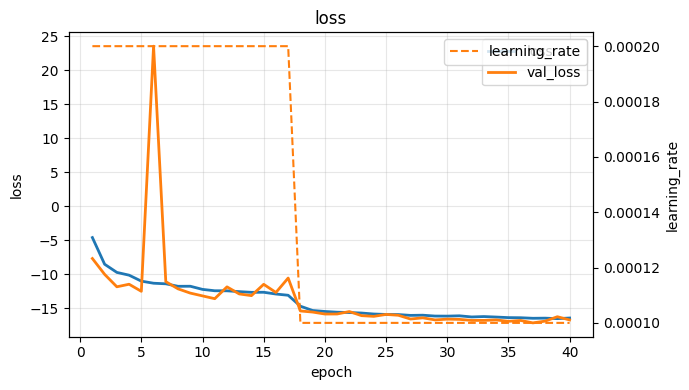

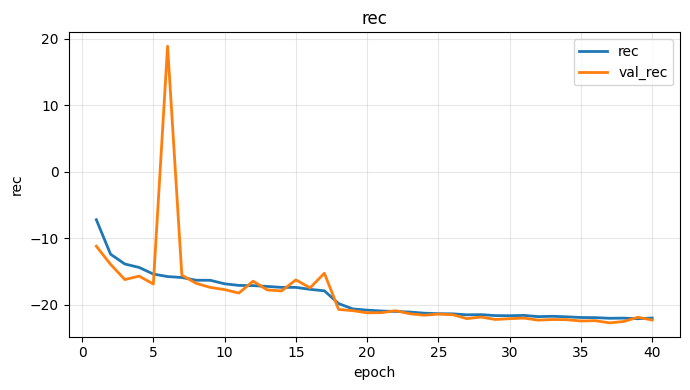

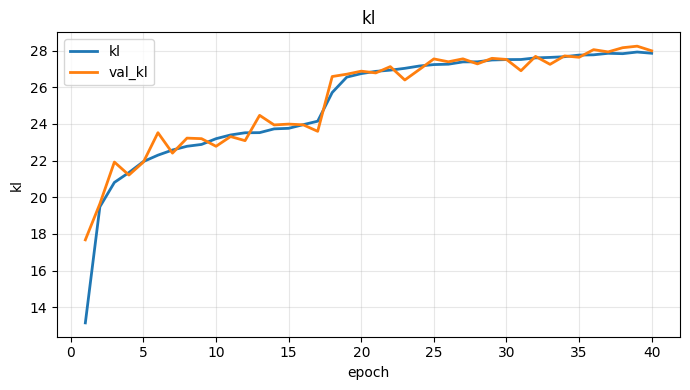

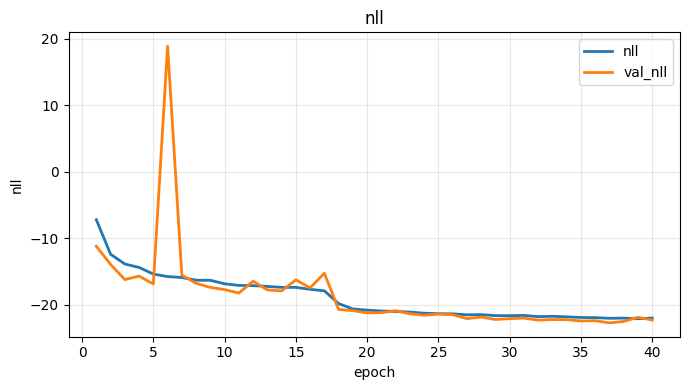

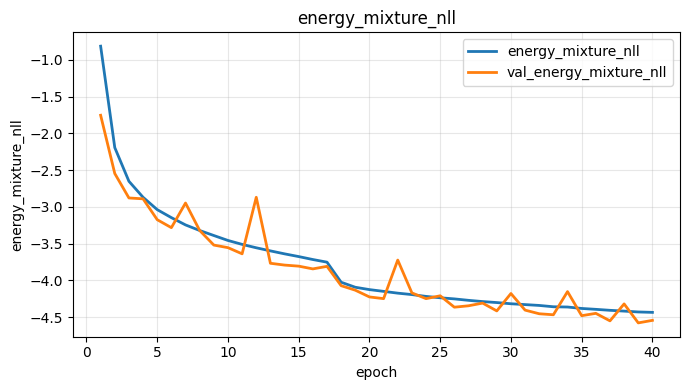

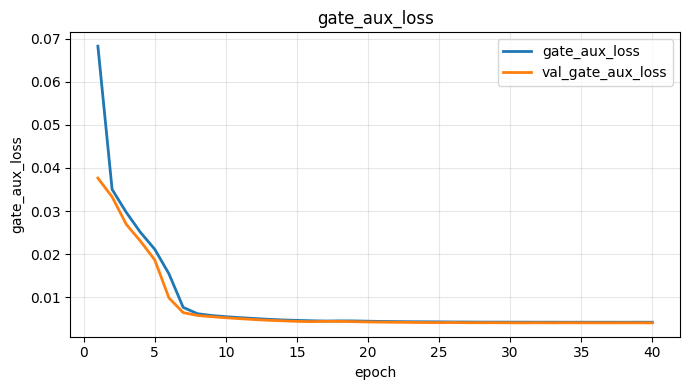

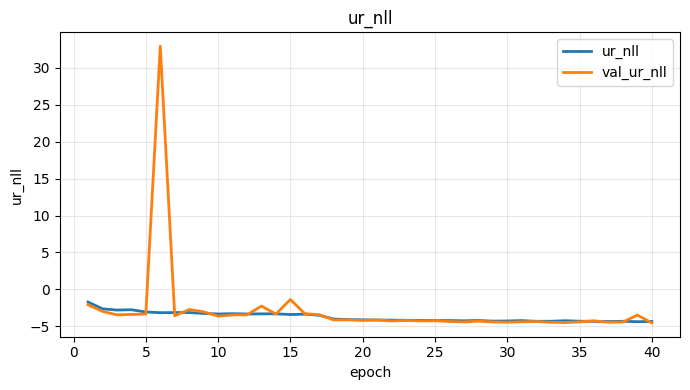

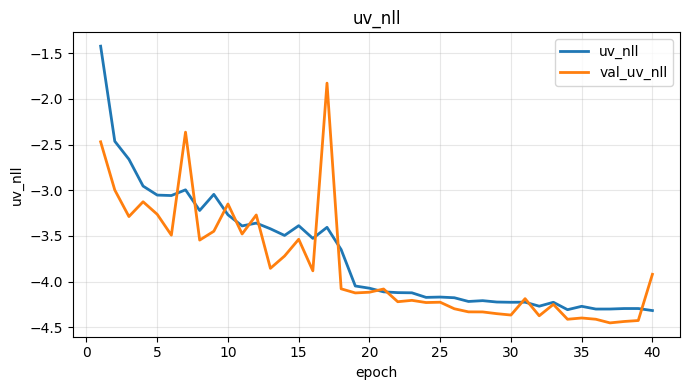

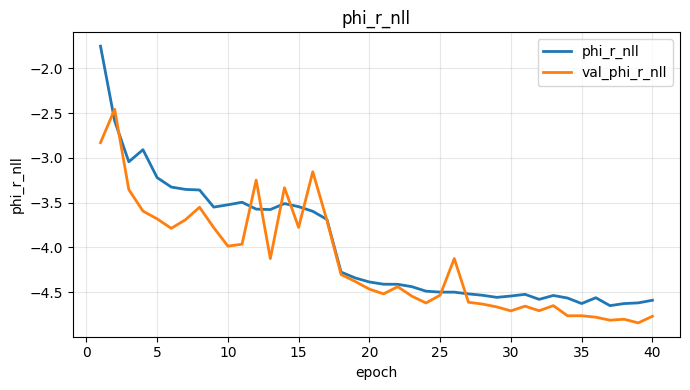

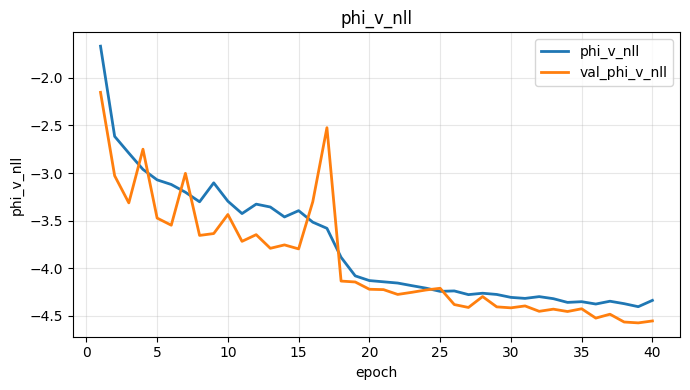

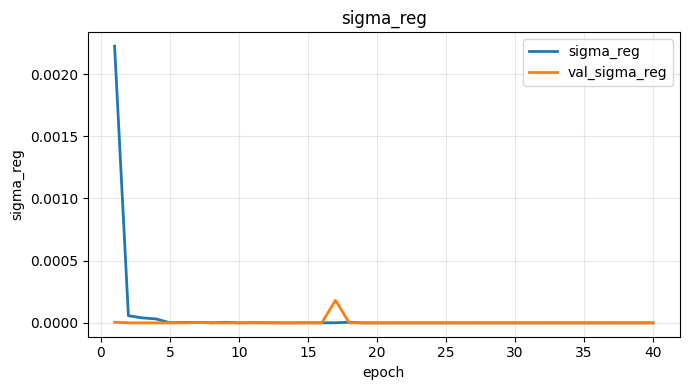

In [22]:
# v0.8 metric set: energy_mixture_nll replaces v0.7.2's energy_ce, and
# gate_aux_loss is the line-routing supervision to watch.
magi.plot_history(
    history,
    keys=[
        "loss",
        "rec",
        "kl",
        "nll",
        "energy_mixture_nll",
        "gate_aux_loss",
        "ur_nll",
        "uv_nll",
        "phi_r_nll",
        "phi_v_nll",
        "sigma_reg",
    ],
)

## Saving Model

`model.to_generation_config()` is the important part: it captures everything the
loader needs to rebuild this exact architecture (line positions, continuum mode,
flow hyperparameters **and the CDF warp knots**, prior type, focal gamma, per-line
widths and their trainability). That is why the reload cell above only has to read
the JSON back instead of retyping a config dict like v0.7.2 did.

In [ ]:
# ==========================================================
# Final model saving with metadata - v0.8
# ==========================================================

save_dir = f"{DRIVE}/trained_models/v0_8_2_{SOURCE}_ingoingfix"
os.makedirs(save_dir, exist_ok=True)
model_name = f"mix_{SOURCE}"

save_info = magi.save_final_trained_model(
    model=model,
    save_dir=save_dir,
    model_name=model_name,
    history=history,
    model_config=model.to_generation_config(),   # self-describing, authoritative
    preprocessing_metadata=preprocessing_metadata,
    training_metadata={
        "source": SOURCE,
        "epochs_requested": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "seed": 42,
        "geometry_mode": "quantile_u_r_u_v_phi_r_phi_v",
        "energy_transform": "log10",
        "training_set": "alloutputDSCryoSphereCR_ingoingfix.dat",
        "device": "colab-gpu",
        "magi_commit": GIT_SHA,
    },
    callbacks=callbacks,
    notes=(
        "v0.8.2 mixture energy head: conditional RQS-flow continuum (24 bins, 3 "
        "transforms) with a CDF pre-warp, plus fixed-position Gaussian lines with "
        "widths pinned to the X-IFU 4 eV FWHM resolution. Energy head and gate "
        "conditioned on the latent z (energy_flow_condition='z_cond') with a "
        "learnable conditional coupling prior p(z|cond) additionally conditioned "
        "on the routing zone (prior_zone_conditioning=True), so energy<->geometry "
        "coupling survives generation AND rare-line routing is correctly placed "
        "in latent space. Gate supervised with a focal-weighted auxiliary CE "
        "(w_gate_aux=2.0, gamma=1.0) against the continuum majority, with "
        "resolution-bandwidth gate targets (bandwidth_mode='exact' was tried and "
        "rejected, see docs/v0.8.1_line_truth.md section 14.2). Geometry "
        "unchanged from v0.7.2 (quantile u_r/u_v/phi_r/phi_v)."
    ),
)

import joblib

joblib.dump(
    quantile_transformers,
    f"{save_dir}/{model_name}_quantile_transformers.joblib",
)

print("saved ->", save_dir)

## Verification before you download

Run this, then re-run the same numbers **locally** from the downloaded checkpoint.
If they disagree, the transformers and the weights have come apart — that is the
failure mode this notebook exists to avoid, and it does not raise an exception.

In [ ]:
# Fingerprint the run so the local reload can be checked against it.
import json, numpy as np

fingerprint = {
    "n_types": int(n_types),
    "idx_to_type": {int(k): v for k, v in dict(idx_to_type).items()}
                   if not isinstance(idx_to_type, (list, tuple)) else list(idx_to_type),
    "type_probs": np.asarray(type_probs).tolist(),
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "epochs_run": int(n_epochs_run),
    "final_val_loss": float(history.history["val_loss"][-1]),
    "val_energy_mixture_nll": float(history.history["val_energy_mixture_nll"][-1]),
    "val_kl": float(history.history["val_kl"][-1]),
    "n_line_positions": int(len(line_positions_y)),
}
print(json.dumps(fingerprint, indent=2))

with open(f"{save_dir}/{model_name}_colab_fingerprint.json", "w") as f:
    json.dump(fingerprint, f, indent=2)

print("\nEXPECTED: n_types = 4 (gamma, mu-, e-, e+).")
print("The old checkpoint had 6, including anti_nu_e and nu_mu at ~2.3% each.")
print("If this says 6, the wrong file was loaded.")


In [ ]:
# Everything needed for generation, as one unit.
import os, glob
print("saved artifacts:")
for p in sorted(glob.glob(f"{save_dir}/*")):
    print(f"  {os.path.getsize(p)/1e6:8.2f} MB  {os.path.basename(p)}")

!cd "{save_dir}/.." && zip -qr "/content/v0_8_2_CR_ingoingfix.zip" "$(basename '{save_dir}')"
print("\nzip -> /content/v0_8_2_CR_ingoingfix.zip  (also already in Drive at save_dir)")
